In [1]:
import pandas as pd

In [58]:
paths = ['/mnt/c/Users/Acer/Downloads/cabrobo2024.csv', '/mnt/c/Users/Acer/Downloads/cabrobo2025.csv']
all_dfs = []
for p in paths:
    df = pd.read_csv(p, sep=';', decimal = ',')
    df= df[((df['Hora (UTC)'] >=900) & (df['Hora (UTC)'] <=2100))]
    df['date'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
    df = df.sort_values(['date', 'Hora (UTC)' ])
    display(df['Radiacao (KJ/m²)'].isna().value_counts())
    df['Radiacao (KJ/m²)'] = df['Radiacao (KJ/m²)'].interpolate()
    all_dfs.append(df[['date', 'Hora (UTC)','Radiacao (KJ/m²)']])

pd.concat(all_dfs).rename(columns={'Radiacao (KJ/m²)':'y'})['y'].to_csv('cabrobo.txt', index=False)
pd.concat(all_dfs).shape

Radiacao (KJ/m²)
False    4755
True        3
Name: count, dtype: int64

Radiacao (KJ/m²)
False    4646
True       99
Name: count, dtype: int64

(9503, 3)

In [50]:
paths = ['/mnt/c/Users/Acer/Downloads/ibimirim2024.csv', '/mnt/c/Users/Acer/Downloads/ibimirim2025.csv']
all_dfs = []
for p in paths:
    df = pd.read_csv(p, sep=';', decimal = ',')
    df= df[((df['Hora (UTC)'] >=900) & (df['Hora (UTC)'] <=2100))]
    df['date'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
    df = df.sort_values(['date', 'Hora (UTC)' ])
    display(df['Radiacao (KJ/m²)'].isna().value_counts())
    df['Radiacao (KJ/m²)'] = df['Radiacao (KJ/m²)'].interpolate()
    all_dfs.append(df[['date', 'Hora (UTC)','Radiacao (KJ/m²)']])

pd.concat(all_dfs).rename(columns={'Radiacao (KJ/m²)':'y'})['y'].to_csv('ibimirim.csv')
pd.concat(all_dfs).shape

Radiacao (KJ/m²)
True     2723
False    2035
Name: count, dtype: int64

Radiacao (KJ/m²)
True     2723
False    2035
Name: count, dtype: int64

(9516, 3)

In [57]:
paths = ['/mnt/c/Users/Acer/Downloads/ouricuri2024.csv', '/mnt/c/Users/Acer/Downloads/ouricuri2025.csv']
all_dfs = []
for p in paths:
    df = pd.read_csv(p, sep=';', decimal = ',')
    df= df[((df['Hora (UTC)'] >=900) & (df['Hora (UTC)'] <=2100))]
    df['date'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
    df = df.sort_values(['date', 'Hora (UTC)' ])
    display(df['Radiacao (KJ/m²)'].isna().value_counts(normalize=True))
    df['Radiacao (KJ/m²)'] = df['Radiacao (KJ/m²)'].interpolate()
    all_dfs.append(df[['date', 'Hora (UTC)','Radiacao (KJ/m²)']])

pd.concat(all_dfs).rename(columns={'Radiacao (KJ/m²)':'y'})['y'].to_csv('ouricuri.txt', index=False)
pd.concat(all_dfs).shape

Radiacao (KJ/m²)
False    0.900799
True     0.099201
Name: proportion, dtype: float64

Radiacao (KJ/m²)
False    0.982719
True     0.017281
Name: proportion, dtype: float64

(9503, 3)

In [56]:
paths = ['/mnt/c/Users/Acer/Downloads/salgueiro2024.csv', '/mnt/c/Users/Acer/Downloads/salgueiro2025.csv']
all_dfs = []
for p in paths:
    df = pd.read_csv(p, sep=';', decimal = ',')
    df= df[((df['Hora (UTC)'] >=900) & (df['Hora (UTC)'] <=2100))]
    df['date'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
    df = df.sort_values(['date', 'Hora (UTC)' ])
    display(df['Radiacao (KJ/m²)'].isna().value_counts(normalize=True))
    df['Radiacao (KJ/m²)'] = df['Radiacao (KJ/m²)'].interpolate()
    all_dfs.append(df[['date', 'Hora (UTC)','Radiacao (KJ/m²)']])

pd.concat(all_dfs).rename(columns={'Radiacao (KJ/m²)':'y'})['y'].to_csv('salgueiro.txt', index=False)
pd.concat(all_dfs).shape

Radiacao (KJ/m²)
False    0.997898
True     0.002102
Name: proportion, dtype: float64

Radiacao (KJ/m²)
False    0.998103
True     0.001897
Name: proportion, dtype: float64

(9503, 3)

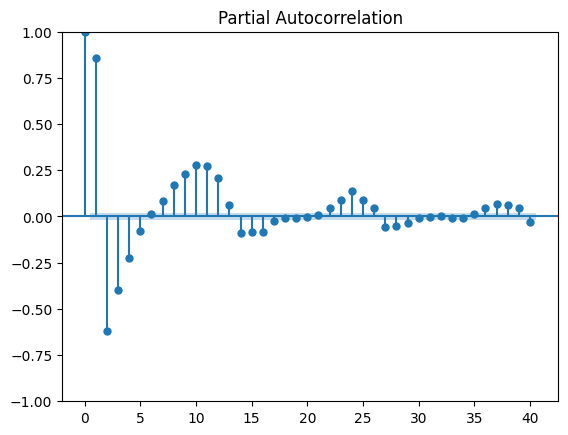

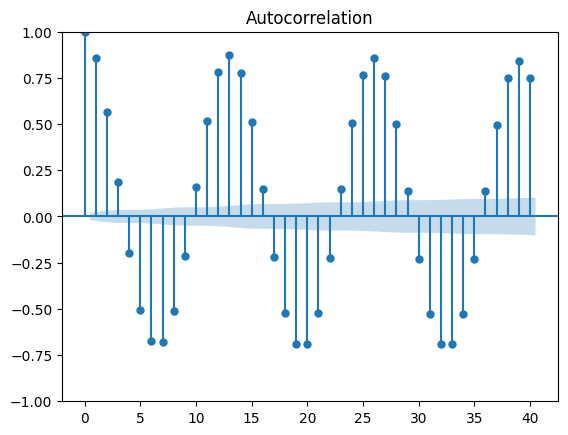

In [61]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
ts = pd.concat(all_dfs).rename(columns={'Radiacao (KJ/m²)':'y'})['y']
plot_pacf(ts)
plt.show()
plot_acf(ts)
plt.show()